# Fig 5: Consumer-Resource Model Fitting

Hyperparameter search, trajectory fits (nitrate + biomass), and null model comparisons.

In [1]:
%cd /home/schmittms/project_vitelli_matthew/scifi_public/fig5_consumer_resource/

import sys, os
sys.path.insert(0, '/home/schmittms/project_vitelli_matthew/scifi_public/')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import IPython

from dataset import SoilDatasetFiltered

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set1.colors)
plt.rcParams['figure.figsize'] = [3, 2]
plt.rcParams['figure.dpi'] = 200
plt.rcParams['svg.fonttype'] = 'none'

/project/vitelli/matthew/scifi_public/fig5_consumer_resource


/project/vitelli/matthew/torch_venv/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Load hyperparameter search results

In [2]:
root = '/project/vitelli/matthew/soil_microbiome_model_reduction/function_driven_clustering/model_fitting_consumer_resource/runs'

print(np.asarray(os.listdir(os.path.join(root, 'fig5_hparam'))))

hparam_path = os.path.join(root, 'fig5_hparam/260223_110813_seed-0/fig5_hparam_search_results.npz')
hparam_payload = np.load(hparam_path, allow_pickle=True)['payload'][0]

print('Hparam keys:')
print(sorted(hparam_payload.keys()))

['260223_110813_seed-0' '260223_104858_seed-0' '260223_104330_seed-0']
Hparam keys:
['args', 'chosen_ens', 'compute_device', 'ensembles_to_keep', 'fullfit', 'gamma0_grid', 'gamma1_grid', 'grid_avg_errors', 'grid_search_errors', 'grid_std_errors', 'loss_df', 'mass_weight_grid', 'mse_biomass_0_array', 'mse_biomass_0_std_array', 'mse_biomass_1_array', 'mse_biomass_1_std_array', 'mse_growth_array', 'mse_growth_std_array', 'no3_chl', 'no3_growth', 'rC_grid', 'sample_subset', 'subroots', 'time_chl', 'time_growth', 'total_errors_array', 'x_final_growth', 'x_init_growth']


## Hyperparameter grid error maps

/scratch/local/jobs/48048936/ipykernel_4088778/3954028603.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


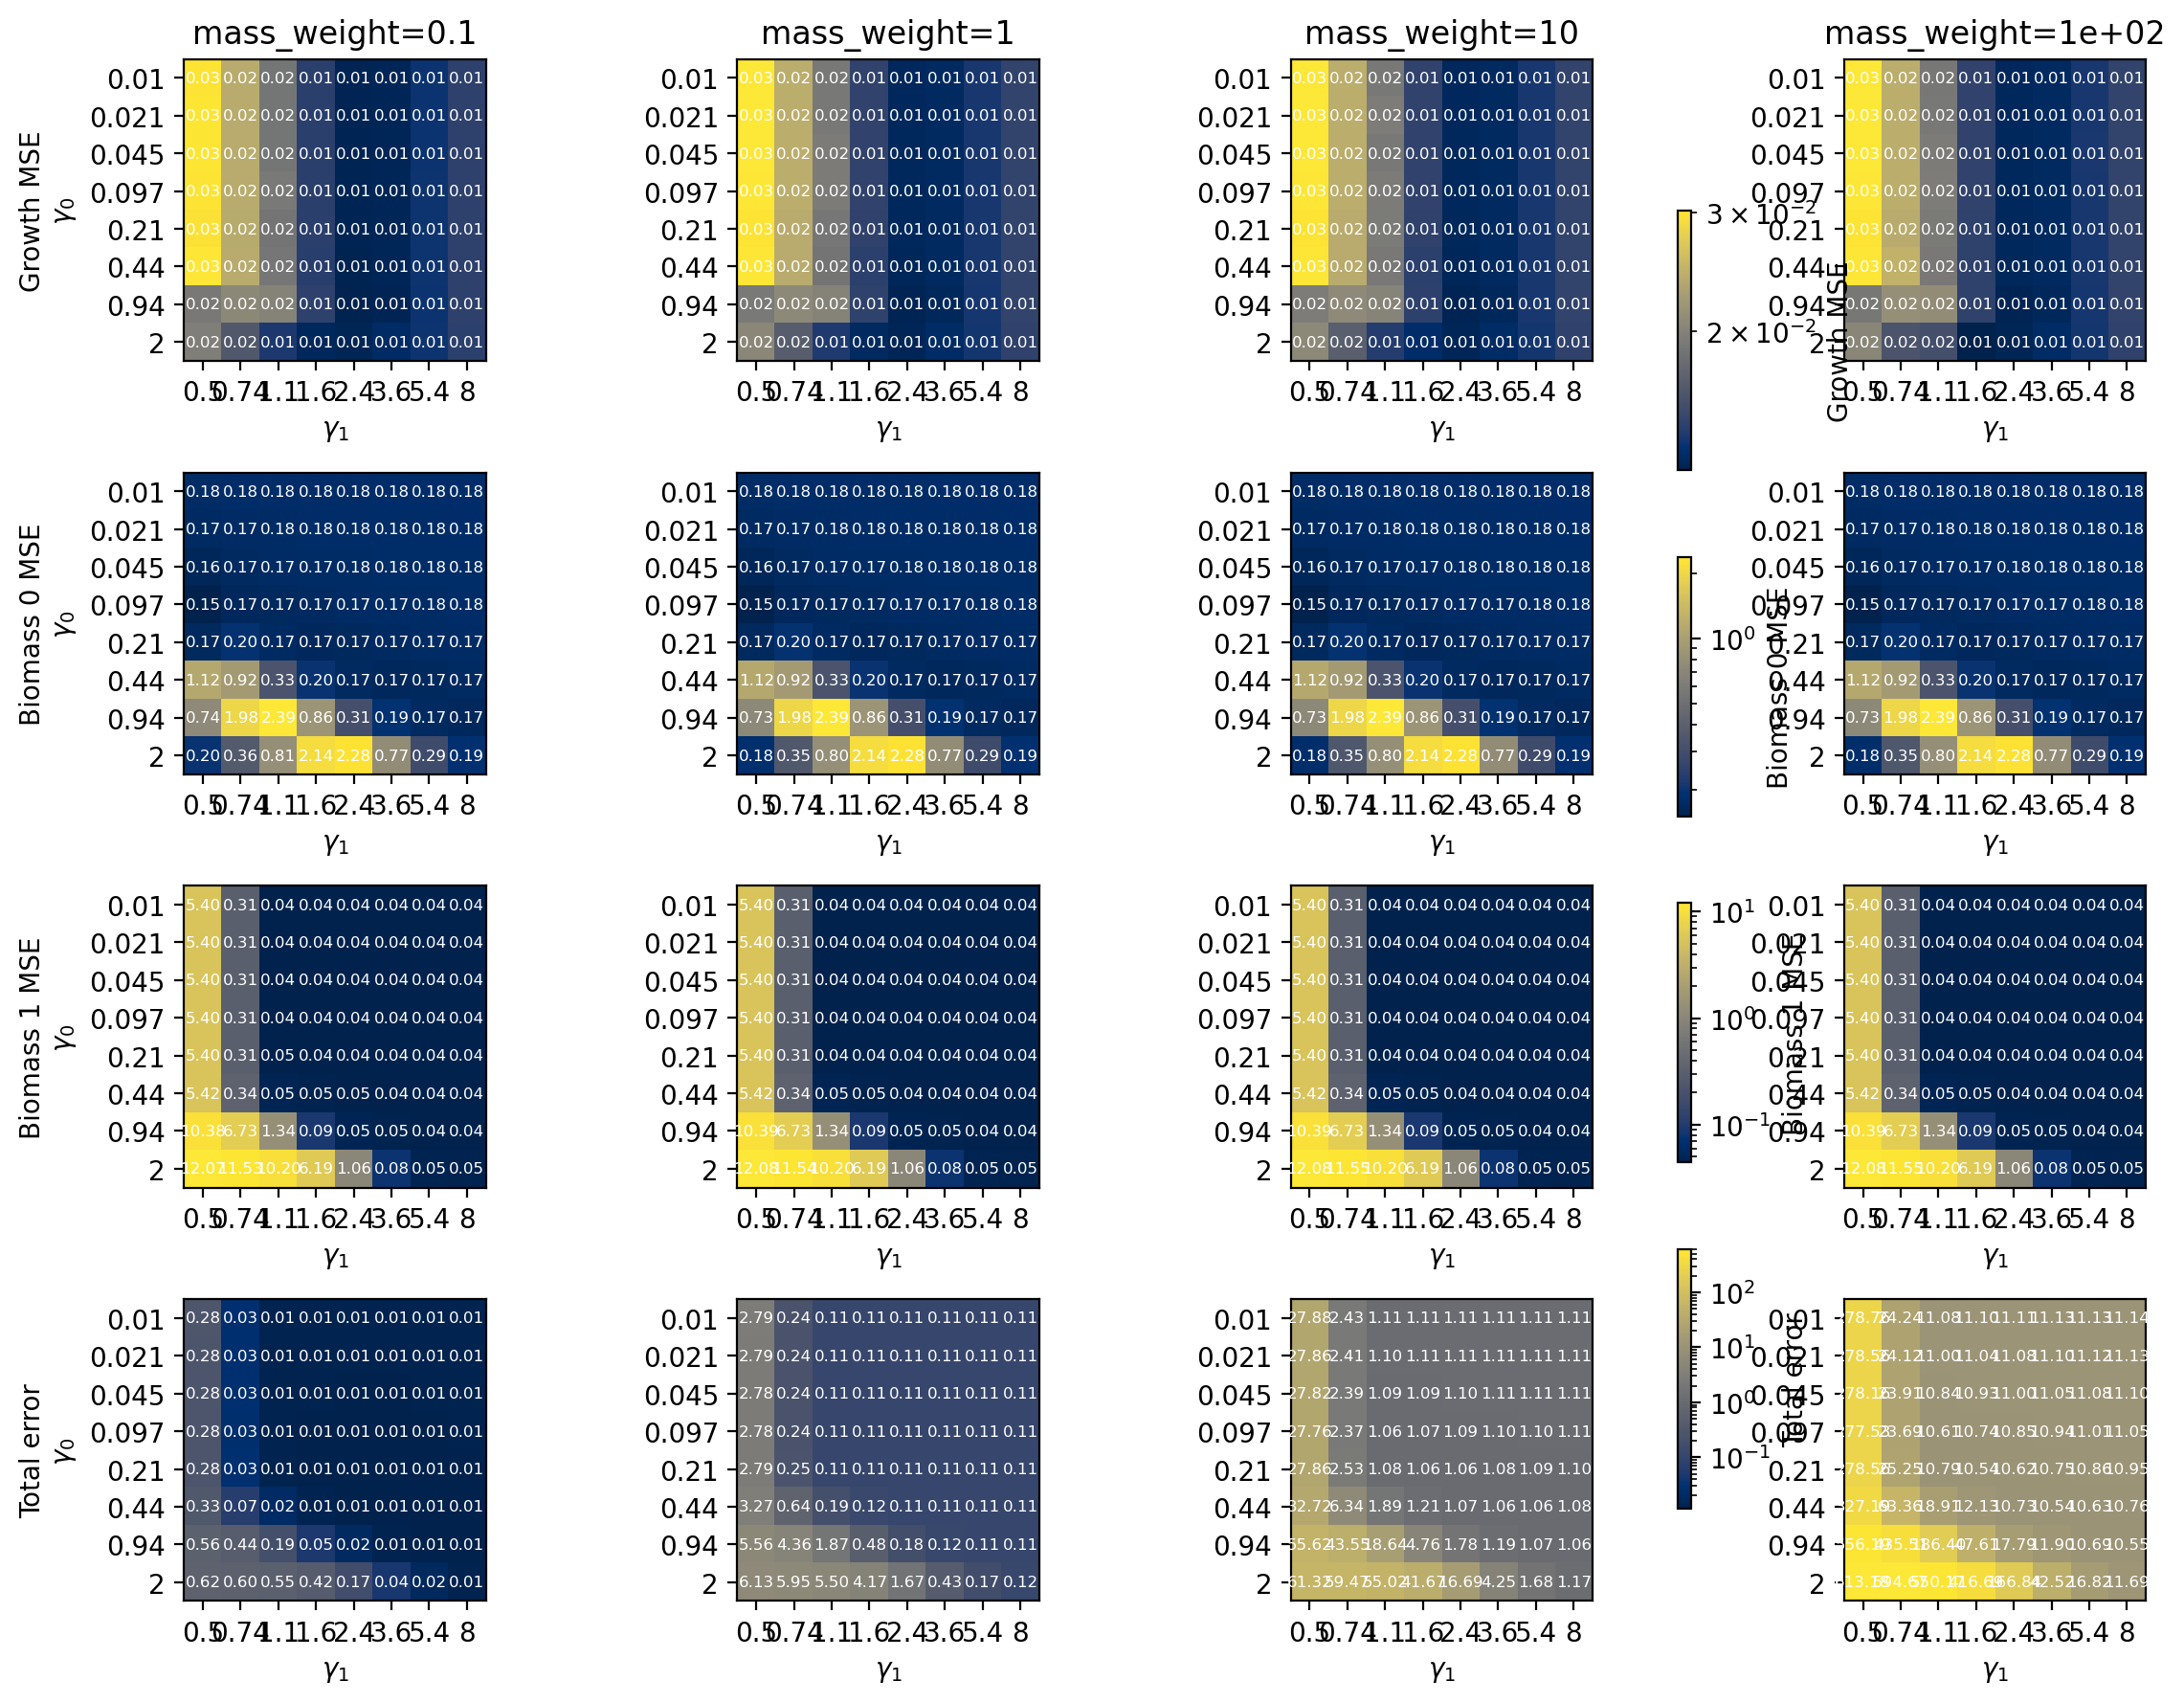

In [3]:
gamma0_grid = np.asarray(hparam_payload['gamma0_grid'])
gamma1_grid = np.asarray(hparam_payload['gamma1_grid'])
rC_grid = np.asarray(hparam_payload['rC_grid'])
mass_weight_grid = np.asarray(hparam_payload['mass_weight_grid'])

total_errors_array = np.asarray(hparam_payload['total_errors_array'])
mse_growth_array = np.asarray(hparam_payload['mse_growth_array'])
mse_biomass_0_array = np.asarray(hparam_payload['mse_biomass_0_array'])
mse_biomass_1_array = np.asarray(hparam_payload['mse_biomass_1_array'])

fig, ax = plt.subplots(4, len(mass_weight_grid), figsize=(3 * len(mass_weight_grid), 9), dpi=200)
if len(mass_weight_grid) == 1:
    ax = np.asarray(ax).reshape(4, 1)

cmap = 'cividis'
for mw_idx in range(len(mass_weight_grid)):
    growth_map = np.min(mse_growth_array[:, :, :, mw_idx], axis=2)
    b0_map = np.min(mse_biomass_0_array[:, :, :, mw_idx], axis=2)
    b1_map = np.min(mse_biomass_1_array[:, :, :, mw_idx], axis=2)
    total_map = np.min(total_errors_array[:, :, :, mw_idx], axis=2)

    im0 = ax[0, mw_idx].imshow(growth_map, cmap=cmap, norm=mcolors.LogNorm(vmin=np.min(mse_growth_array), vmax=np.max(mse_growth_array)))
    im1 = ax[1, mw_idx].imshow(b0_map, cmap=cmap, norm=mcolors.LogNorm(vmin=np.min(mse_biomass_0_array), vmax=np.max(mse_biomass_0_array)))
    im2 = ax[2, mw_idx].imshow(b1_map, cmap=cmap, norm=mcolors.LogNorm(vmin=np.min(mse_biomass_1_array), vmax=np.max(mse_biomass_1_array)))
    im3 = ax[3, mw_idx].imshow(total_map, cmap=cmap, norm=mcolors.LogNorm(vmin=np.min(total_errors_array), vmax=np.max(total_errors_array)))

    for i in range(len(gamma0_grid)):
        for j in range(len(gamma1_grid)):
            ax[0, mw_idx].text(j, i, f'{growth_map[i, j]:.2f}', color='w', ha='center', va='center', fontsize=6)
            ax[1, mw_idx].text(j, i, f'{b0_map[i, j]:.2f}', color='w', ha='center', va='center', fontsize=6)
            ax[2, mw_idx].text(j, i, f'{b1_map[i, j]:.2f}', color='w', ha='center', va='center', fontsize=6)
            ax[3, mw_idx].text(j, i, f'{total_map[i, j]:.2f}', color='w', ha='center', va='center', fontsize=6)

    for a in ax[:, mw_idx]:
        a.set_xticks(np.arange(len(gamma1_grid)))
        a.set_yticks(np.arange(len(gamma0_grid)))
        a.set_xticklabels([f'{g:.2g}' for g in gamma1_grid])
        a.set_yticklabels([f'{g:.2g}' for g in gamma0_grid])
        a.set_xlabel('$\\gamma_1$')

    ax[0, mw_idx].set_title(f'mass_weight={mass_weight_grid[mw_idx]:.2g}')

ax[0, 0].set_ylabel('Growth MSE\n$\\gamma_0$')
ax[1, 0].set_ylabel('Biomass 0 MSE\n$\\gamma_0$')
ax[2, 0].set_ylabel('Biomass 1 MSE\n$\\gamma_0$')
ax[3, 0].set_ylabel('Total error\n$\\gamma_0$')

fig.colorbar(im0, ax=ax[0, :], shrink=0.9, label='Growth MSE')
fig.colorbar(im1, ax=ax[1, :], shrink=0.9, label='Biomass 0 MSE')
fig.colorbar(im2, ax=ax[2, :], shrink=0.9, label='Biomass 1 MSE')
fig.colorbar(im3, ax=ax[3, :], shrink=0.9, label='Total error')

plt.tight_layout()

In [4]:
grid_avg = hparam_payload['grid_avg_errors'].copy()
best_idx = int(grid_avg['total_error'].idxmin())
best_row = grid_avg.loc[best_idx]

print('Best parameter set by mean total_error:')
display(best_row[['param_set', 'gamma0', 'gamma1', 'r_C', 'mass_weight', 'total_error', 'mse_growth', 'mse_biomass0', 'mse_biomass1']])

Best parameter set by mean total_error:


param_set       180.000000
gamma0            0.440142
gamma1            3.622895
r_C               1.000000
mass_weight       0.100000
total_error       0.011663
mse_growth        0.012755
mse_biomass0      0.166478
mse_biomass1      0.044598
Name: 180, dtype: float64

## Load datasets and fitted trajectories

In [5]:
fullfit = hparam_payload['fullfit']

no3_growth = np.asarray(hparam_payload['no3_growth'])
time_growth = np.asarray(hparam_payload['time_growth'], dtype=object)
x_init_growth = np.asarray(hparam_payload['x_init_growth'])
x_final_growth = np.asarray(hparam_payload['x_final_growth'])

A_growth_preds = np.asarray(fullfit['A_growth_preds'])
x_growth_preds = np.asarray(fullfit['x_growth_preds'])
A_growth_exact_interp = fullfit.get('A_growth_exact_interp', None)
x_growth_exact_interp = fullfit.get('x_growth_exact_interp', None)

loss_df = hparam_payload['loss_df']
train_kwargs = loss_df.iloc[0]['train_dataset_kwargs'].copy()
train_kwargs['device'] = 'cpu'
dataset_train = SoilDatasetFiltered(**train_kwargs)

## Trajectory fits for a single native pH

In [6]:
CHL_mask = dataset_train.df.Chloramphenicol == 1
native_phs = np.sort(np.unique(dataset_train.soil_ph[~CHL_mask]))[[-2]]

ph_pair_indices = []
for ph in native_phs:
    native_mask = dataset_train.soil_ph[~CHL_mask].detach().cpu().numpy() == ph
    perturb_units = np.unique(dataset_train.df.Unit[~CHL_mask].values[native_mask])[::-1]

    indices = []
    for unit in perturb_units:
        idx = np.where(
            (dataset_train.soil_ph[~CHL_mask].detach().cpu().numpy() == ph) &
            (dataset_train.df.Unit[~CHL_mask].values == unit)
        )[0]
        indices.append(idx)

    ph_pair_indices.append(indices)

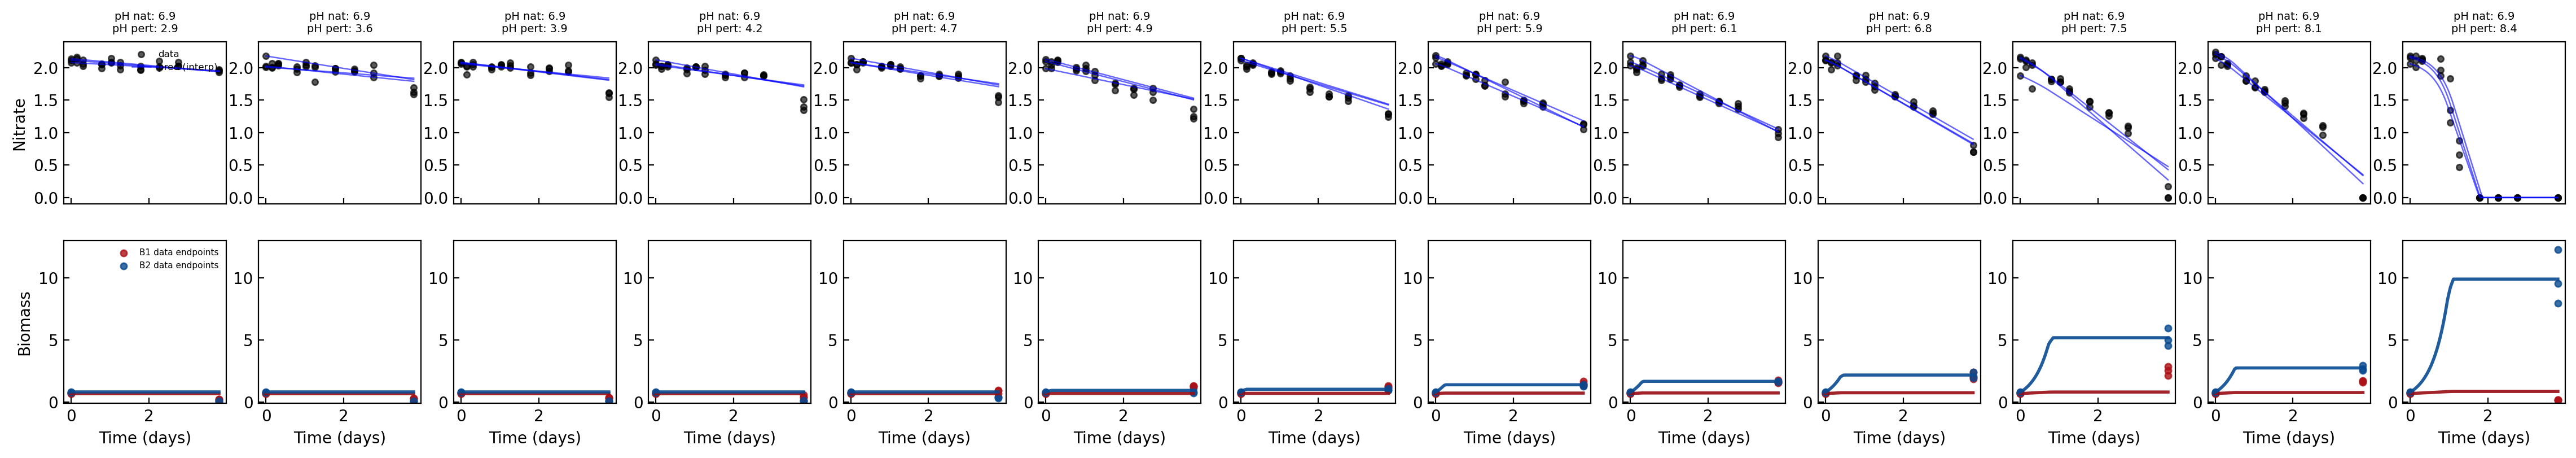

In [7]:
fig, ax = plt.subplots(2, len(ph_pair_indices[0]),
                       figsize=(2.2 * len(ph_pair_indices[0]), 4.2), dpi=200,
                       squeeze=False, sharex=True)

for j in range(len(ph_pair_indices[0])):
    x1_traj_avg = np.mean(x_growth_exact_interp[
        [ph_pair_indices[0][j][r] for r in range(len(ph_pair_indices[0][j]))], 0, :], axis=0)
    x2_traj_avg = np.mean(x_growth_exact_interp[
        [ph_pair_indices[0][j][r] for r in range(len(ph_pair_indices[0][j]))], 1, :], axis=0)

    for r in range(len(ph_pair_indices[0][j])):
        sidx = ph_pair_indices[0][j][r]
        t_obs = np.asarray(time_growth[sidx])
        t0, t1 = t_obs[0], t_obs[-1]

        A_true = no3_growth[sidx]
        ph_nat = dataset_train.soil_ph.detach().cpu().numpy()[~CHL_mask][sidx]
        ph_pert = dataset_train.ph.detach().cpu().numpy()[~CHL_mask][sidx]

        ax[0, j].scatter(t_obs, A_true, color='k', s=14,
                         alpha=0.8 if len(ph_pair_indices[0][j]) <= 2 else 0.65,
                         label='data' if (j == 0 and r == 0) else None)

        t_interp = np.linspace(0, t1, A_growth_exact_interp.shape[-1])
        ax[0, j].plot(t_interp, A_growth_exact_interp[sidx], color='b', lw=0.9,
                      alpha=0.6, label='pred (interp)' if (j == 0 and r == 0) else None)

        ax[1, j].scatter([t0, t1], [x_init_growth[sidx, 0], x_final_growth[sidx, 0]],
                         color=plt.get_cmap('Reds')(0.85), s=16, alpha=0.8,
                         label='B1 data endpoints' if (j == 0 and r == 0) else None)
        ax[1, j].scatter([t0, t1], [x_init_growth[sidx, 1], x_final_growth[sidx, 1]],
                         color=plt.get_cmap('Blues')(0.90), s=16, alpha=0.8,
                         label='B2 data endpoints' if (j == 0 and r == 0) else None)

    ax[1, j].plot(t_interp, x1_traj_avg, color=plt.get_cmap('Reds')(0.9), lw=2, alpha=0.9)
    ax[1, j].plot(t_interp, x2_traj_avg, color=plt.get_cmap('Blues')(0.9), lw=2, alpha=0.9)

    ax[0, j].set_title(f'pH nat: {ph_nat:0.1f}\npH pert: {ph_pert:0.1f}', fontsize=7)

for a in ax.flat:
    a.tick_params(axis='both', direction='in')

ax[0, 0].set_ylabel('Nitrate')
ax[1, 0].set_ylabel('Biomass')
for j in range(len(ph_pair_indices[0])):
    ax[1, j].set_xlabel('Time (days)')

ax[0, 0].legend(frameon=False, fontsize=6, loc='upper right')
ax[1, 0].legend(frameon=False, fontsize=5.5, loc='upper right')

for a in ax[0]:
    a.set_ylim(-0.1, 2.4)
for a in ax[1]:
    a.set_ylim(-0.1, 13)
for a in ax.flat:
    a.set_box_aspect(1)

import datetime, pprint
if input('save? ').strip().lower() == 'save':
    savepath = './figures/fig5_opt_hparams_trajectories_single_nat_ph.svg'
    fig.savefig(savepath, bbox_inches='tight')

    grid_avg_local = hparam_payload['grid_avg_errors'].copy()
    best_idx_local = int(grid_avg_local['total_error'].idxmin())
    best_row_local = grid_avg_local.loc[best_idx_local]

    metadata_lines = [
        f'Saved UTC: {datetime.datetime.utcnow().isoformat()}Z',
        f'hparam_path: {hparam_path}',
        f'Nat pH selection: {native_phs.tolist()}',
        f'Best param_set: {best_row_local["param_set"]}',
        f'Best gamma0: {best_row_local["gamma0"]}',
        f'Best gamma1: {best_row_local["gamma1"]}',
        f'Best r_C: {best_row_local["r_C"]}',
        f'Best mass_weight: {best_row_local["mass_weight"]}',
        f'Best total_error: {best_row_local["total_error"]}',
        f'Grid gamma0: {np.asarray(hparam_payload["gamma0_grid"]).tolist()}',
        f'Grid gamma1: {np.asarray(hparam_payload["gamma1_grid"]).tolist()}',
        f'Grid r_C: {np.asarray(hparam_payload["rC_grid"]).tolist()}',
        f'Grid mass_weight: {np.asarray(hparam_payload["mass_weight_grid"]).tolist()}',
        f'train_dataset_kwargs: {pprint.pformat(train_kwargs, compact=True)}',
        f'hparam script args: {pprint.pformat(hparam_payload.get("args", {}), compact=True)}',
    ]
    metadata_str = '\n'.join(metadata_lines)
    open(savepath, 'a').write(f"<!-- Metadata:\n{metadata_str}\n-->\n")
    print(f'Saved {savepath} with metadata footer.')

## Null model comparisons

In [8]:
null_path_both = os.path.join(root, 'fig5_null_parallel/260223_141046_seed-0_nullmode-median2_n_nulls_-500_subset_size-100_njobs-8/fig5_null_comparison_results_parallel.npz')
null_path_only_vary_bm1 = os.path.join(root, 'null_modeling_parallel/260223_151217_s-0_nm-median2_ns-biomass1_nn-500_ss-100_nj-8/fig5_null_comparison_results_parallel.npz')
null_path_only_vary_bm12 = os.path.join(root, 'null_modeling_parallel/260223_151231_s-0_nm-median2_ns-biomass2_nn-500_ss-100_nj-8/fig5_null_comparison_results_parallel.npz')

null_payload_both = np.load(null_path_both, allow_pickle=True)['payload'][0]
null_payload_bm1 = np.load(null_path_only_vary_bm1, allow_pickle=True)['payload'][0]
null_payload_bm2 = np.load(null_path_only_vary_bm12, allow_pickle=True)['payload'][0]

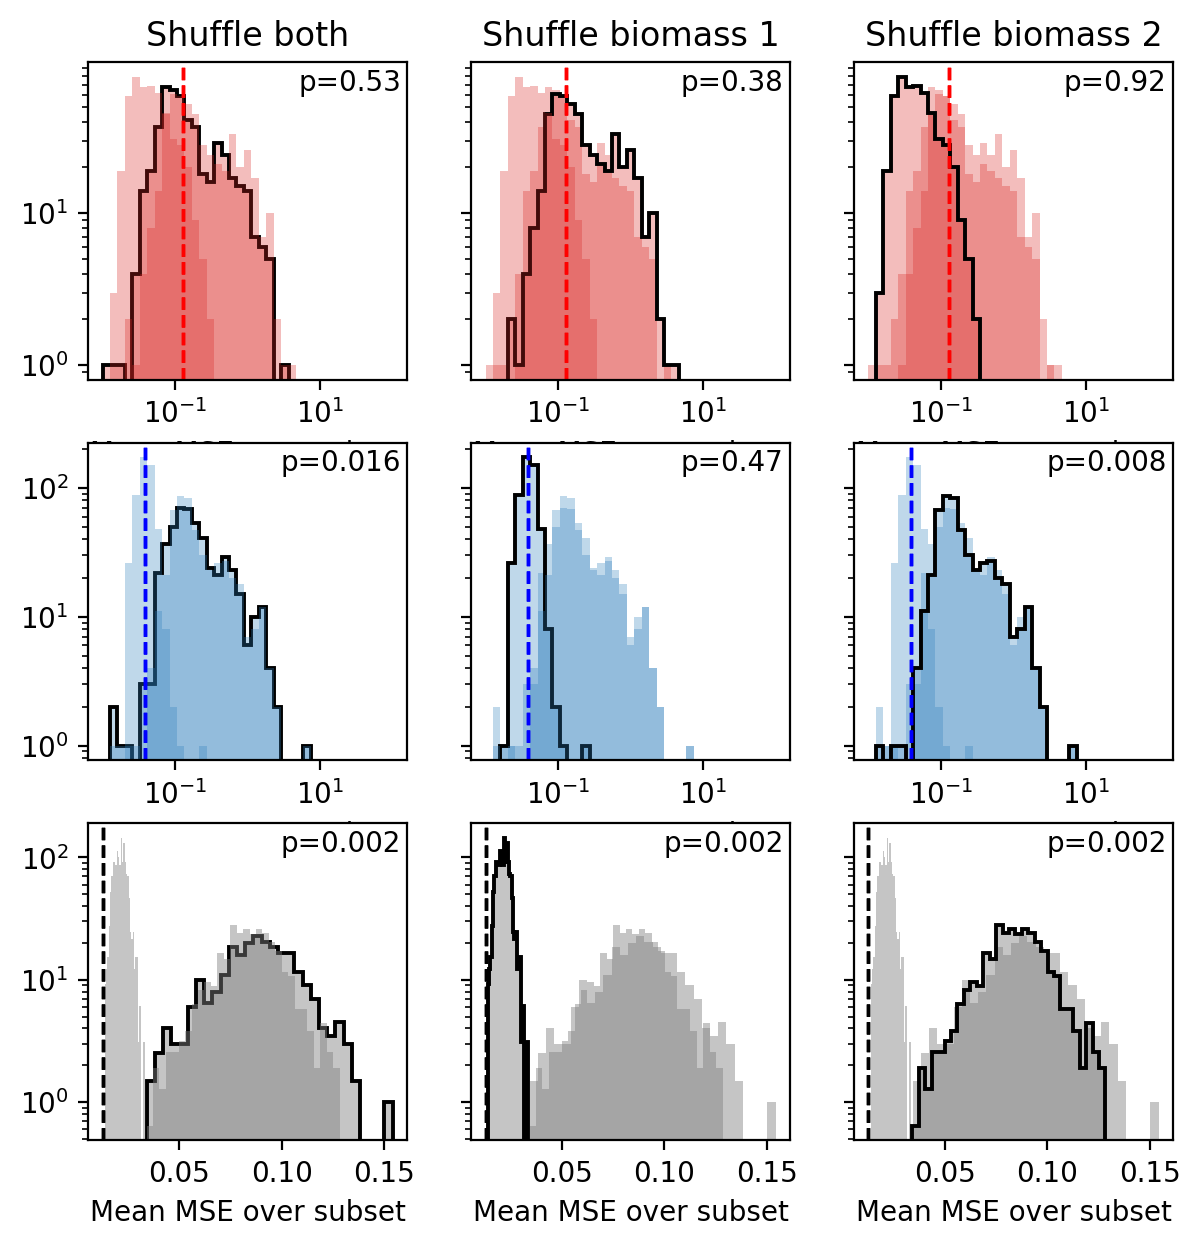

In [9]:
fig, ax = plt.subplots(3, 3, figsize=(7, 7), dpi=200)
ax = ax.T

for i, null_payload in enumerate([null_payload_both, null_payload_bm1, null_payload_bm2]):
    results = null_payload['results']
    summary = null_payload['summary']

    biomass_errors_ensemble = results['biomass_errors_ensemble']
    nitrate_errors_ensemble = results['nitrate_errors_ensemble']

    fake_bio_mean = np.mean(biomass_errors_ensemble['Fake'], axis=1)
    real_bio_mean = np.mean(biomass_errors_ensemble['Real'], axis=1)
    fake_nit_mean = np.mean(nitrate_errors_ensemble['Fake'], axis=1)
    real_nit_mean = np.mean(nitrate_errors_ensemble['Real'], axis=1)

    logbins = np.logspace(-2, 2, 40)

    for a in ax[:, 0]:
        a.hist(fake_bio_mean[:, 0], bins=logbins, alpha=0.3,
               color=plt.get_cmap('Reds')(0.7), label='Null g0', density=False)
        a.axvline(np.mean(real_bio_mean[:, 0]), color='r', ls='--', lw=1.2,
                  label='Real g0 mean')

    for a in ax[:, 1]:
        a.hist(fake_bio_mean[:, 1], bins=logbins, alpha=0.3,
               color=plt.get_cmap('Blues')(0.7), label='Null g1', density=False)
        a.axvline(np.mean(real_bio_mean[:, 1]), color='b', ls='--', lw=1.2,
                  label='Real g1 mean')

    for a in ax[:, 2]:
        a.hist(fake_nit_mean, bins=30, alpha=0.45, color='gray', label='Null', density=True)
        a.axvline(np.mean(real_nit_mean), color='k', ls='--', lw=1.2)
        a.set_yscale('log')

    H0, b0 = np.histogram(fake_bio_mean[:, 0], bins=logbins, density=False)
    ax[i][0].stairs(H0, b0, color='k', lw=1.4)

    H1, b1 = np.histogram(fake_bio_mean[:, 1], bins=logbins, density=False)
    ax[i][1].stairs(H1, b1, color='k', lw=1.4)

    Hn, bn = np.histogram(fake_nit_mean, bins=30, density=True)
    ax[i][2].stairs(Hn, bn, color='k', lw=1.4)

    ax[i][0].text(0.98, 0.98, f"p={summary['pvalue_biomass0']:.2g}",
                  ha='right', va='top', transform=ax[i][0].transAxes)
    ax[i][1].text(0.98, 0.98, f"p={summary['pvalue_biomass1']:.2g}",
                  ha='right', va='top', transform=ax[i][1].transAxes)
    ax[i][2].text(0.98, 0.98, f"p={summary['pvalue_nitrate']:.2g}",
                  ha='right', va='top', transform=ax[i][2].transAxes)

for a in ax[:, :2].flat:
    a.set_xscale('log')
    a.set_yscale('log')
    a.set_xlabel('Mean MSE over subset')

for a in ax[:, 2]:
    a.set_xlabel('Mean MSE over subset')

for a in ax[1:].flat:
    a.set_yticklabels([])

ax[0][0].set_title('Shuffle both')
ax[1][0].set_title('Shuffle biomass 1')
ax[2][0].set_title('Shuffle biomass 2')

if input('save? ').strip().lower() == 'save':
    savepath = './figures/SI_fig5_null_models.svg'
    fig.savefig(savepath, bbox_inches='tight')
    metadata_str = f"Null model both params: {null_payload_both['args']}\n\n"
    metadata_str += f"Null model shuffle bm1: {null_payload_bm1['args']}\n\n"
    metadata_str += f"Null model shuffle bm2: {null_payload_bm2['args']}\n\n"
    open(savepath, 'a').write(f"<!-- Metadata:\n{metadata_str} \n-->\n")